<>:82: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:83: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:84: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:82: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:83: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:84: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\yesyo\AppData\Local\Temp\ipykernel_92672\2722683438.py:82: SyntaxWa


🚀 CNN 모델 학습 시작...


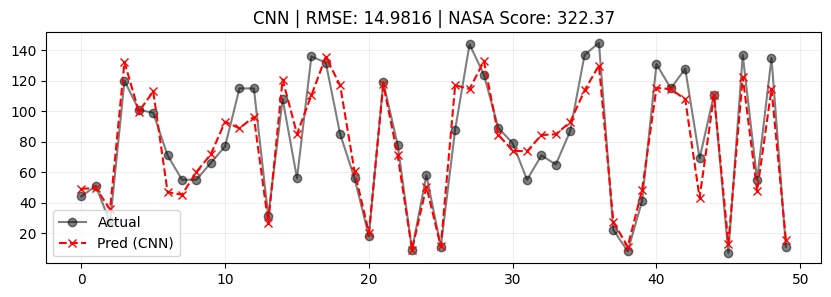


🚀 LSTM 모델 학습 시작...


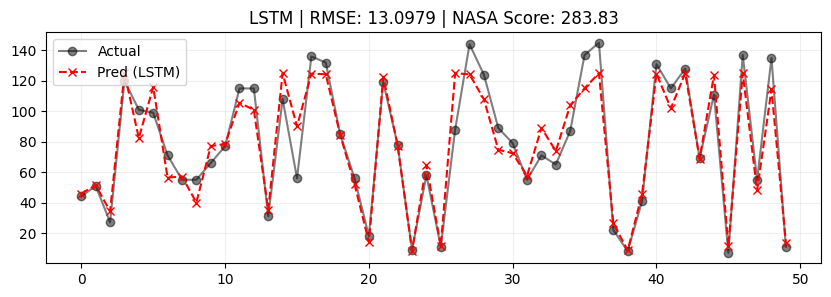


🚀 BiLSTM 모델 학습 시작...


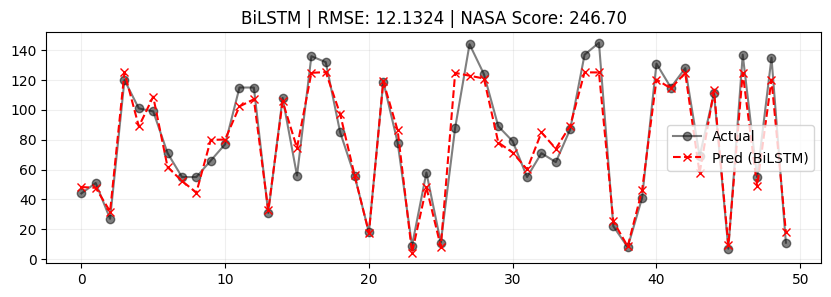


🚀 Transformer 모델 학습 시작...


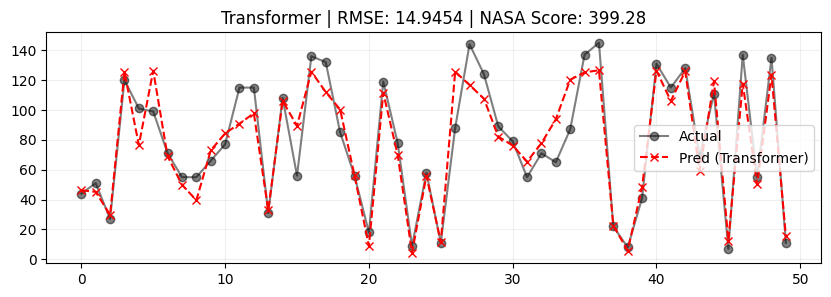


🚀 CNN+Transformer 모델 학습 시작...


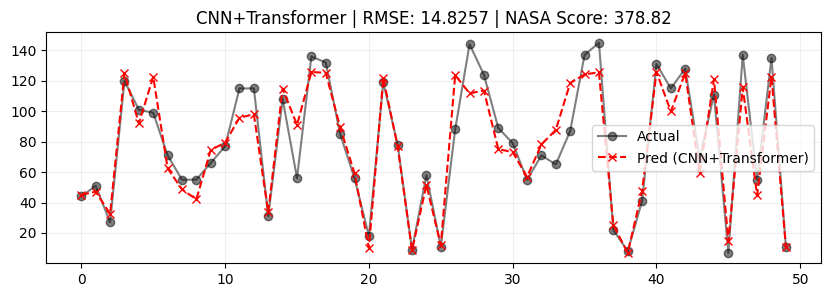


🏆 딥러닝 모델 성능 비교 요약
          Model      RMSE  NASA Score
            CNN 14.981610  322.365113
           LSTM 13.097912  283.830046
         BiLSTM 12.132388  246.699222
    Transformer 14.945433  399.275774
CNN+Transformer 14.825683  378.822384


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from scipy.ndimage import gaussian_filter1d
from scipy.stats import mannwhitneyu
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# ==========================================
# [1] 실험 설정 구간 (기존 CONFIG 유지 + 딥러닝 설정 추가)
# ==========================================
DATA_PATH = '../../CMAPSSData/'
CONFIG = {
    'DATA_ID': 'FD003',
    'RUL_CAP': 125,
    'GAUSS_SIGMA': 2,
    'RANDOM_STATE': 42,
    'TEST_SIZE': 0.2,
    'SCALER_TYPE': 'standard', 
    'SELECTED_SENSORS': ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 
                         's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21'], 
    'SETTING_FEATURES': ['setting_1', 'setting_2'],
    'USE_MA': False,   'WIN_MA': 5,
    'USE_STD': True,  'WIN_STD': 60,  
    'USE_DIFF': True, 'PER_DIFF': 60,
    'USE_EMA': False,  'SPAN_EMA': 10,
    'USE_LAG': False,
    
    # 딥러닝 전용 설정
    'WINDOW_SIZE': 30,
    'BATCH_SIZE': 64,
    'EPOCHS': 50,
    'LEARNING_RATE': 0.001,
    'DEVICE': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# ---------------------------------------------------------
# [2] 전처리 및 데이터셋 생성 로직
# ---------------------------------------------------------
def get_sensors_by_config(df, config):
    all_possible_sensors = [f's_{i}' for i in range(1, 22)]
    if config['SELECTED_SENSORS'] == 'all':
        sig_sensors = [s for s in all_possible_sensors if df[s].std() > 1e-6]
    elif config['SELECTED_SENSORS'] == 'auto':
        max_cycles = df.groupby('unit_nr')['time_cycles'].transform('max')
        early_stage = df[df['time_cycles'] <= 30]
        late_stage = df[df['time_cycles'] > (max_cycles - 30)]
        sig_sensors = []
        for s in all_possible_sensors:
            if df[s].std() < 1e-6: continue
            _, p = mannwhitneyu(early_stage[s], late_stage[s], alternative='two-sided')
            if p < 0.01: sig_sensors.append(s)
    elif isinstance(config['SELECTED_SENSORS'], list):
        sig_sensors = [s for s in config['SELECTED_SENSORS'] if s in df.columns]
    return sig_sensors

def add_advanced_features(df, sensors, config):
    df_res = df.copy()
    for col in sensors:
        group = df_res.groupby('unit_nr')[col]
        if config['USE_MA']:   df_res[f'{col}_ma'] = group.transform(lambda x: x.rolling(config['WIN_MA'], min_periods=1).mean())
        if config['USE_STD']:  df_res[f'{col}_std'] = group.transform(lambda x: x.rolling(config['WIN_STD'], min_periods=1).std().fillna(0))
        if config['USE_DIFF']: df_res[f'{col}_diff'] = group.transform(lambda x: x.diff(config['PER_DIFF']).fillna(0))
        if config['USE_EMA']:  df_res[f'{col}_ema'] = group.transform(lambda x: x.ewm(span=config['SPAN_EMA'], adjust=False).mean())
    return df_res

def apply_smoothing(df, sigma, sensors):
    df = df.copy().sort_values(['unit_nr', 'time_cycles'])
    for uid in df['unit_nr'].unique():
        mask = df['unit_nr'] == uid
        for col in sensors:
            df.loc[mask, col] = gaussian_filter1d(df.loc[mask, col].astype(float), sigma=sigma, mode='nearest')
    return df

# 데이터 로드
cols = ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3'] + [f's_{i}' for i in range(1, 22)]
train = pd.read_csv(f"{DATA_PATH}train_{CONFIG['DATA_ID']}.txt", sep='\s+', header=None, names=cols)
test = pd.read_csv(f"{DATA_PATH}test_{CONFIG['DATA_ID']}.txt", sep='\s+', header=None, names=cols)
y_test_actual = pd.read_csv(f"{DATA_PATH}RUL_{CONFIG['DATA_ID']}.txt", sep='\s+', header=None, names=['RUL'])['RUL'].values

base_sensors = get_sensors_by_config(train, CONFIG)
train['RUL'] = train.groupby('unit_nr')['time_cycles'].transform(lambda x: (x.max() - x).clip(upper=CONFIG['RUL_CAP']))

# Smoothing & Feature Engineering
train = apply_smoothing(train, CONFIG['GAUSS_SIGMA'], base_sensors)
test = apply_smoothing(test, CONFIG['GAUSS_SIGMA'], base_sensors)
train = add_advanced_features(train, base_sensors, CONFIG)
test = add_advanced_features(test, base_sensors, CONFIG)

# Scaling
scaler = MinMaxScaler() if CONFIG['SCALER_TYPE'] == 'minmax' else StandardScaler()
X_features = base_sensors + CONFIG['SETTING_FEATURES'] + [c for c in train.columns if any(suffix in c for suffix in ['_ma', '_std', '_diff', '_ema'])]
train[X_features] = scaler.fit_transform(train[X_features])
test[X_features] = scaler.transform(test[X_features])

# Windowing 함수
def create_sequences(df, window_size, feature_cols, target_col=None):
    x, y = [], []
    for uid in df['unit_nr'].unique():
        unit_df = df[df['unit_nr'] == uid]
        data = unit_df[feature_cols].values
        if target_col:
            target = unit_df[target_col].values
        for i in range(window_size, len(data) + 1):
            x.append(data[i-window_size:i])
            if target_col:
                y.append(target[i-1])
    return np.array(x), np.array(y)

# Test 데이터는 각 엔진의 마지막 시퀀스만 추출
def create_test_sequences(df, window_size, feature_cols):
    x = []
    for uid in df['unit_nr'].unique():
        unit_df = df[df['unit_nr'] == uid]
        if len(unit_df) >= window_size:
            x.append(unit_df[feature_cols].values[-window_size:])
        else:
            # 윈도우보다 짧을 경우 zero padding
            padding = np.zeros((window_size - len(unit_df), len(feature_cols)))
            x.append(np.vstack([padding, unit_df[feature_cols].values]))
    return np.array(x)

X_train_seq, y_train_seq = create_sequences(train, CONFIG['WINDOW_SIZE'], X_features, 'RUL')
X_test_seq = create_test_sequences(test, CONFIG['WINDOW_SIZE'], X_features)

# Dataset & DataLoader
class CMAPSSDataset(Dataset):
    def __init__(self, x, y=None):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32) if y is not None else None
    def __len__(self): return len(self.x)
    def __getitem__(self, i):
        if self.y is not None: return self.x[i], self.y[i]
        return self.x[i]

train_loader = DataLoader(CMAPSSDataset(X_train_seq, y_train_seq), batch_size=CONFIG['BATCH_SIZE'], shuffle=True)
test_loader = DataLoader(CMAPSSDataset(X_test_seq), batch_size=1, shuffle=False)

# ---------------------------------------------------------
# [3] 모델 정의 구간 (CNN, LSTM, BiLSTM, Transformer, Hybrid)
# ---------------------------------------------------------
input_dim = len(X_features)
win_size = CONFIG['WINDOW_SIZE']

# 1. CNN
class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(input_dim, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(64, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Flatten()
        )
        self.fc = nn.Linear(32 * win_size, 1)
    def forward(self, x):
        x = x.transpose(1, 2) # (batch, feature, seq)
        return self.fc(self.conv(x)).squeeze()

# 2. LSTM / 3. BiLSTM
class RNNModel(nn.Module):
    def __init__(self, bidirectional=False):
        super().__init__()
        self.rnn = nn.LSTM(input_dim, 64, num_layers=2, batch_first=True, bidirectional=bidirectional)
        self.fc = nn.Linear(128 if bidirectional else 64, 1)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :]).squeeze()

# 4. Transformer
class TransformerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Linear(input_dim, 64)
        encoder_layer = nn.TransformerEncoderLayer(d_model=64, nhead=4, dim_feedforward=128, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Linear(64, 1)
    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer(x)
        return self.fc(x[:, -1, :]).squeeze()

# 5. CNN + Transformer
class CNNTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv1d(input_dim, 64, kernel_size=3, padding=1)
        encoder_layer = nn.TransformerEncoderLayer(d_model=64, nhead=4, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Linear(64, 1)
    def forward(self, x):
        x = self.conv(x.transpose(1, 2)).transpose(1, 2)
        x = self.transformer(x)
        return self.fc(x[:, -1, :]).squeeze()

# ---------------------------------------------------------
# [4] 학습 및 평가 루프
# ---------------------------------------------------------
def get_nasa_score(y_true, y_pred):
    d = y_pred - y_true
    return np.sum(np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1))

models = {
    'CNN': CNNModel(),
    'LSTM': RNNModel(bidirectional=False),
    'BiLSTM': RNNModel(bidirectional=True),
    'Transformer': TransformerModel(),
    'CNN+Transformer': CNNTransformer()
}

results = []

for name, model in models.items():
    print(f"\n🚀 {name} 모델 학습 시작...")
    model.to(CONFIG['DEVICE'])
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=CONFIG['LEARNING_RATE'])
    
    model.train()
    for epoch in range(CONFIG['EPOCHS']):
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(CONFIG['DEVICE']), batch_y.to(CONFIG['DEVICE'])
            optimizer.zero_grad()
            output = model(batch_x)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()
    
    # 평가
    model.eval()
    y_pred = []
    with torch.no_grad():
        for batch_x in test_loader:
            batch_x = batch_x.to(CONFIG['DEVICE'])
            y_pred.append(model(batch_x).item())
    
    y_pred = np.array(y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
    score = get_nasa_score(y_test_actual, y_pred)
    
    # 시각화
    plt.figure(figsize=(10, 3))
    plt.plot(y_test_actual[:50], 'ko-', label='Actual', alpha=0.5)
    plt.plot(y_pred[:50], 'rx--', label=f'Pred ({name})')
    plt.title(f"{name} | RMSE: {rmse:.4f} | NASA Score: {score:.2f}")
    plt.legend(); plt.grid(True, alpha=0.2); plt.show()
    
    results.append([name, rmse, score])

print("\n🏆 딥러닝 모델 성능 비교 요약")
print(pd.DataFrame(results, columns=['Model', 'RMSE', 'NASA Score']).to_string(index=False))

<>:82: SyntaxWarning: invalid escape sequence '\s'
<>:83: SyntaxWarning: invalid escape sequence '\s'
<>:84: SyntaxWarning: invalid escape sequence '\s'
<>:82: SyntaxWarning: invalid escape sequence '\s'
<>:83: SyntaxWarning: invalid escape sequence '\s'
<>:84: SyntaxWarning: invalid escape sequence '\s'
C:\Users\yesyo\AppData\Local\Temp\ipykernel_27628\2807532600.py:82: SyntaxWarning: invalid escape sequence '\s'
  train = pd.read_csv(f"{DATA_PATH}train_{CONFIG['DATA_ID']}.txt", sep='\s+', header=None, names=cols)
C:\Users\yesyo\AppData\Local\Temp\ipykernel_27628\2807532600.py:83: SyntaxWarning: invalid escape sequence '\s'
  test = pd.read_csv(f"{DATA_PATH}test_{CONFIG['DATA_ID']}.txt", sep='\s+', header=None, names=cols)
C:\Users\yesyo\AppData\Local\Temp\ipykernel_27628\2807532600.py:84: SyntaxWarning: invalid escape sequence '\s'
  y_test_actual = pd.read_csv(f"{DATA_PATH}RUL_{CONFIG['DATA_ID']}.txt", sep='\s+', header=None, names=['RUL'])['RUL'].values
C:\Users\yesyo\AppData\Local


🚀 CNN 모델 학습 시작 (AdamW & Scheduler 적용)...


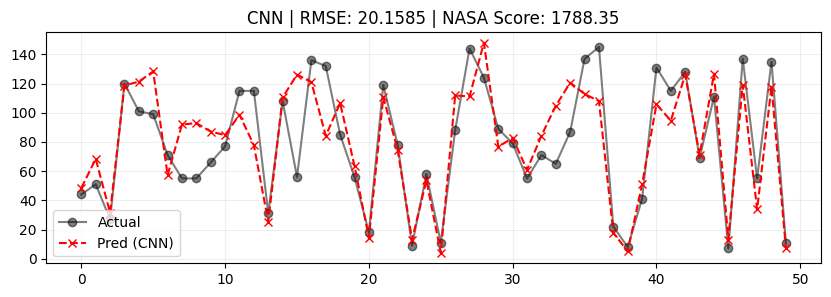


🚀 LSTM 모델 학습 시작 (AdamW & Scheduler 적용)...


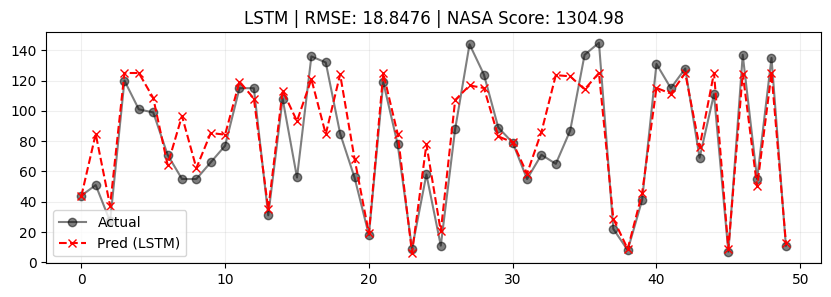


🚀 BiLSTM 모델 학습 시작 (AdamW & Scheduler 적용)...


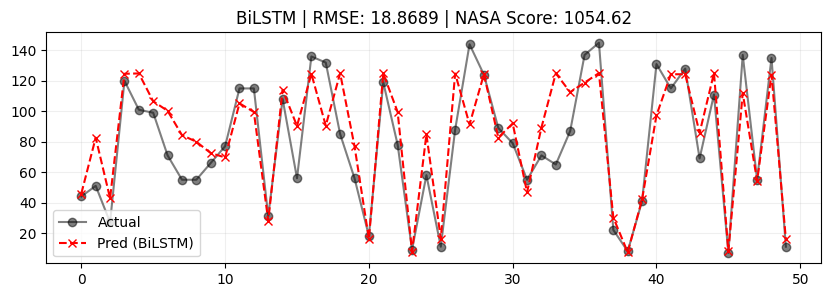


🚀 Transformer 모델 학습 시작 (AdamW & Scheduler 적용)...


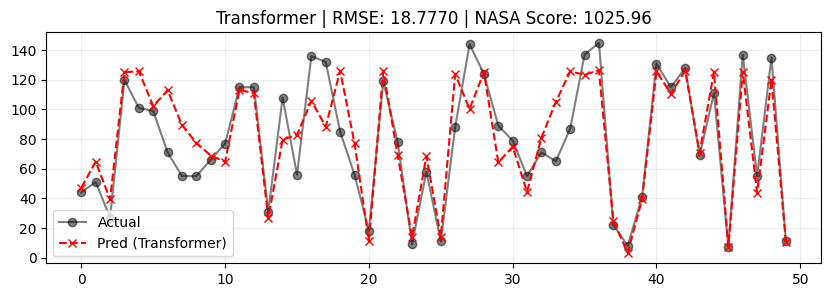


🚀 CNN+Transformer 모델 학습 시작 (AdamW & Scheduler 적용)...


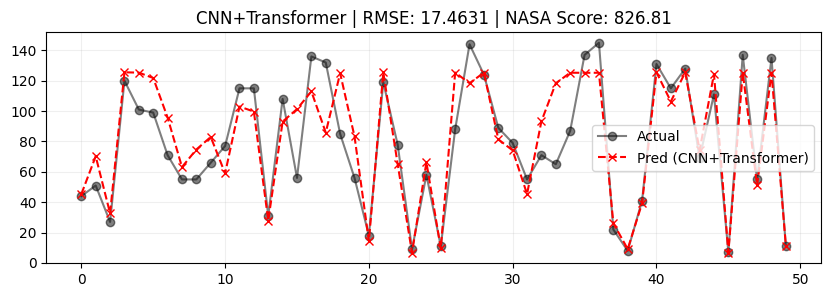


🏆 딥러닝 모델 최종 성능 비교
          Model      RMSE  NASA Score
            CNN 20.158523 1788.352299
           LSTM 18.847566 1304.981962
         BiLSTM 18.868947 1054.624123
    Transformer 18.777000 1025.955574
CNN+Transformer 17.463119  826.813066


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import math
from torch.utils.data import DataLoader, Dataset
from torch.optim.lr_scheduler import CosineAnnealingLR
from scipy.ndimage import gaussian_filter1d
from scipy.stats import mannwhitneyu
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# ==========================================
# [1] 실험 설정 구간 (CONFIG)
# ==========================================
DATA_PATH = '../CMAPSSData/'
CONFIG = {
    'DATA_ID': 'FD003',
    'RUL_CAP': 125,
    'GAUSS_SIGMA': 2,
    'RANDOM_STATE': 42,
    'TEST_SIZE': 0.2,
    'SCALER_TYPE': 'standard', 
    'SELECTED_SENSORS': 'auto', 
    'SETTING_FEATURES': ['setting_1', 'setting_2'],
    'USE_MA': False,   'WIN_MA': 5,
    'USE_STD': True,  'WIN_STD': 60,  
    'USE_DIFF': True, 'PER_DIFF': 60,
    'USE_EMA': False,  'SPAN_EMA': 10,
    
    # 딥러닝 전용 설정
    'WINDOW_SIZE': 30,
    'BATCH_SIZE': 128,
    'EPOCHS': 60,
    'LEARNING_RATE': 0.001,
    'DEVICE': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# ---------------------------------------------------------
# [2] 전처리 및 데이터셋 생성 로직
# ---------------------------------------------------------
def get_sensors_by_config(df, config):
    all_possible_sensors = [f's_{i}' for i in range(1, 22)]
    if config['SELECTED_SENSORS'] == 'all':
        sig_sensors = [s for s in all_possible_sensors if df[s].std() > 1e-6]
    elif config['SELECTED_SENSORS'] == 'auto':
        max_cycles = df.groupby('unit_nr')['time_cycles'].transform('max')
        early_stage = df[df['time_cycles'] <= 30]
        late_stage = df[df['time_cycles'] > (max_cycles - 30)]
        sig_sensors = []
        for s in all_possible_sensors:
            if df[s].std() < 1e-6: continue
            _, p = mannwhitneyu(early_stage[s], late_stage[s], alternative='two-sided')
            if p < 0.01: sig_sensors.append(s)
    elif isinstance(config['SELECTED_SENSORS'], list):
        sig_sensors = [s for s in config['SELECTED_SENSORS'] if s in df.columns]
    return sig_sensors

def add_advanced_features(df, sensors, config):
    df_res = df.copy()
    for col in sensors:
        group = df_res.groupby('unit_nr')[col]
        if config['USE_MA']:   df_res[f'{col}_ma'] = group.transform(lambda x: x.rolling(config['WIN_MA'], min_periods=1).mean())
        if config['USE_STD']:  df_res[f'{col}_std'] = group.transform(lambda x: x.rolling(config['WIN_STD'], min_periods=1).std().fillna(0))
        if config['USE_DIFF']: df_res[f'{col}_diff'] = group.transform(lambda x: x.diff(config['PER_DIFF']).fillna(0))
        if config['USE_EMA']:  df_res[f'{col}_ema'] = group.transform(lambda x: x.ewm(span=config['SPAN_EMA'], adjust=False).mean())
    return df_res

def apply_smoothing(df, sigma, sensors):
    df = df.copy().sort_values(['unit_nr', 'time_cycles'])
    for uid in df['unit_nr'].unique():
        mask = df['unit_nr'] == uid
        for col in sensors:
            df.loc[mask, col] = gaussian_filter1d(df.loc[mask, col].astype(float), sigma=sigma, mode='nearest')
    return df

# 데이터 로드
cols = ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3'] + [f's_{i}' for i in range(1, 22)]
train = pd.read_csv(f"{DATA_PATH}train_{CONFIG['DATA_ID']}.txt", sep='\s+', header=None, names=cols)
test = pd.read_csv(f"{DATA_PATH}test_{CONFIG['DATA_ID']}.txt", sep='\s+', header=None, names=cols)
y_test_actual = pd.read_csv(f"{DATA_PATH}RUL_{CONFIG['DATA_ID']}.txt", sep='\s+', header=None, names=['RUL'])['RUL'].values

base_sensors = get_sensors_by_config(train, CONFIG)
train['RUL'] = train.groupby('unit_nr')['time_cycles'].transform(lambda x: (x.max() - x).clip(upper=CONFIG['RUL_CAP']))

train = apply_smoothing(train, CONFIG['GAUSS_SIGMA'], base_sensors)
test = apply_smoothing(test, CONFIG['GAUSS_SIGMA'], base_sensors)
train = add_advanced_features(train, base_sensors, CONFIG)
test = add_advanced_features(test, base_sensors, CONFIG)

scaler = MinMaxScaler() if CONFIG['SCALER_TYPE'] == 'minmax' else StandardScaler()
X_features = base_sensors + CONFIG['SETTING_FEATURES'] + [c for c in train.columns if any(suffix in c for suffix in ['_ma', '_std', '_diff', '_ema'])]
train[X_features] = scaler.fit_transform(train[X_features])
test[X_features] = scaler.transform(test[X_features])

def create_sequences(df, window_size, feature_cols, target_col=None):
    x, y = [], []
    for uid in df['unit_nr'].unique():
        unit_df = df[df['unit_nr'] == uid]
        data = unit_df[feature_cols].values
        if target_col:
            target = unit_df[target_col].values
        for i in range(window_size, len(data) + 1):
            x.append(data[i-window_size:i])
            if target_col:
                y.append(target[i-1])
    return np.array(x), np.array(y)

def create_test_sequences(df, window_size, feature_cols):
    x = []
    for uid in df['unit_nr'].unique():
        unit_df = df[df['unit_nr'] == uid]
        if len(unit_df) >= window_size:
            x.append(unit_df[feature_cols].values[-window_size:])
        else:
            padding = np.zeros((window_size - len(unit_df), len(feature_cols)))
            x.append(np.vstack([padding, unit_df[feature_cols].values]))
    return np.array(x)

X_train_seq, y_train_seq = create_sequences(train, CONFIG['WINDOW_SIZE'], X_features, 'RUL')
X_test_seq = create_test_sequences(test, CONFIG['WINDOW_SIZE'], X_features)

class CMAPSSDataset(Dataset):
    def __init__(self, x, y=None):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32) if y is not None else None
    def __len__(self): return len(self.x)
    def __getitem__(self, i):
        if self.y is not None: return self.x[i], self.y[i]
        return self.x[i]

train_loader = DataLoader(CMAPSSDataset(X_train_seq, y_train_seq), batch_size=CONFIG['BATCH_SIZE'], shuffle=True)
test_loader = DataLoader(CMAPSSDataset(X_test_seq), batch_size=1, shuffle=False)

# ---------------------------------------------------------
# [3] 모델 정의 구간 (Positional Encoding 추가)
# ---------------------------------------------------------
input_dim = len(X_features)
win_size = CONFIG['WINDOW_SIZE']

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

# 1. CNN (기존)
class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(input_dim, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(64, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Flatten()
        )
        self.fc = nn.Linear(32 * win_size, 1)
    def forward(self, x):
        x = x.transpose(1, 2) # (batch, feature, seq)
        return self.fc(self.conv(x)).squeeze()

# 2. LSTM / 3. BiLSTM
class RNNModel(nn.Module):
    def __init__(self, bidirectional=False):
        super().__init__()
        self.rnn = nn.LSTM(input_dim, 64, num_layers=2, batch_first=True, bidirectional=bidirectional)
        self.fc = nn.Linear(128 if bidirectional else 64, 1)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :]).squeeze()

# 4. Transformer (개선)
class TransformerModel(nn.Module):
    def __init__(self, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=d_model*2, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)
    def forward(self, x):
        x = self.pos_encoder(self.embedding(x))
        x = self.transformer(x)
        return self.fc(x[:, -1, :]).squeeze()

# 5. CNN + Transformer (개선)
class CNNTransformer(nn.Module):
    def __init__(self, d_model=64):
        super().__init__()
        self.conv = nn.Conv1d(input_dim, d_model, kernel_size=3, padding=1)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=4, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Linear(d_model, 1)
    def forward(self, x):
        x = self.conv(x.transpose(1, 2)).transpose(1, 2)
        x = self.pos_encoder(x)
        x = self.transformer(x)
        return self.fc(x[:, -1, :]).squeeze()

# ---------------------------------------------------------
# [4] 학습 및 평가 루프 (AdamW & Scheduler 적용)
# ---------------------------------------------------------
def get_nasa_score(y_true, y_pred):
    d = y_pred - y_true
    return np.sum(np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1))

models_dict = {
    'CNN': CNNModel(),
    'LSTM': RNNModel(bidirectional=False),
    'BiLSTM': RNNModel(bidirectional=True),
    'Transformer': TransformerModel(),
    'CNN+Transformer': CNNTransformer()
}

results = []

for name, model in models_dict.items():
    print(f"\n🚀 {name} 모델 학습 시작 (AdamW & Scheduler 적용)...")
    model.to(CONFIG['DEVICE'])
    criterion = nn.MSELoss()
    
    # BiLSTM, Transformer, CNN+Transformer는 AdamW와 Scheduler 적용
    if name in ['BiLSTM', 'Transformer', 'CNN+Transformer']:
        optimizer = optim.AdamW(model.parameters(), lr=CONFIG['LEARNING_RATE'], weight_decay=0.01)
        scheduler = CosineAnnealingLR(optimizer, T_max=CONFIG['EPOCHS'])
    else:
        optimizer = optim.Adam(model.parameters(), lr=CONFIG['LEARNING_RATE'])
        scheduler = None
    
    model.train()
    for epoch in range(CONFIG['EPOCHS']):
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(CONFIG['DEVICE']), batch_y.to(CONFIG['DEVICE'])
            optimizer.zero_grad()
            output = model(batch_x)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()
        if scheduler:
            scheduler.step()
    
    model.eval()
    y_pred = []
    with torch.no_grad():
        for batch_x in test_loader:
            batch_x = batch_x.to(CONFIG['DEVICE'])
            y_pred.append(model(batch_x).item())
    
    y_pred = np.array(y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
    score = get_nasa_score(y_test_actual, y_pred)
    
    plt.figure(figsize=(10, 3))
    plt.plot(y_test_actual[:50], 'ko-', label='Actual', alpha=0.5)
    plt.plot(y_pred[:50], 'rx--', label=f'Pred ({name})')
    plt.title(f"{name} | RMSE: {rmse:.4f} | NASA Score: {score:.2f}")
    plt.legend(); plt.grid(True, alpha=0.2); plt.show()
    
    results.append([name, rmse, score])

print("\n🏆 딥러닝 모델 최종 성능 비교")
print(pd.DataFrame(results, columns=['Model', 'RMSE', 'NASA Score']).to_string(index=False))

<>:85: SyntaxWarning: invalid escape sequence '\s'
<>:86: SyntaxWarning: invalid escape sequence '\s'
<>:87: SyntaxWarning: invalid escape sequence '\s'
<>:85: SyntaxWarning: invalid escape sequence '\s'
<>:86: SyntaxWarning: invalid escape sequence '\s'
<>:87: SyntaxWarning: invalid escape sequence '\s'
C:\Users\yesyo\AppData\Local\Temp\ipykernel_32288\487702881.py:85: SyntaxWarning: invalid escape sequence '\s'
  train = pd.read_csv(f"{DATA_PATH}train_{CONFIG['DATA_ID']}.txt", sep='\s+', header=None, names=cols)
C:\Users\yesyo\AppData\Local\Temp\ipykernel_32288\487702881.py:86: SyntaxWarning: invalid escape sequence '\s'
  test = pd.read_csv(f"{DATA_PATH}test_{CONFIG['DATA_ID']}.txt", sep='\s+', header=None, names=cols)
C:\Users\yesyo\AppData\Local\Temp\ipykernel_32288\487702881.py:87: SyntaxWarning: invalid escape sequence '\s'
  y_test_actual = pd.read_csv(f"{DATA_PATH}RUL_{CONFIG['DATA_ID']}.txt", sep='\s+', header=None, names=['RUL'])['RUL'].values
C:\Users\yesyo\AppData\Local\Te


🚀 CNN 모델 학습 시작...
✅ CNN 학습 완료 (Best Val Loss: 0.000160)


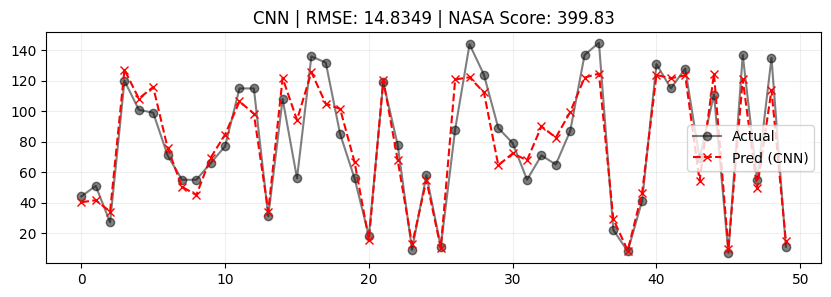


🚀 LSTM 모델 학습 시작...
✅ LSTM 학습 완료 (Best Val Loss: 0.000052)


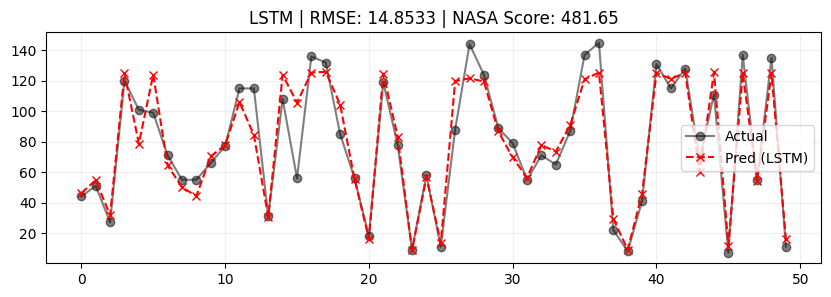


🚀 BiLSTM 모델 학습 시작...
✅ BiLSTM 학습 완료 (Best Val Loss: 0.000020)


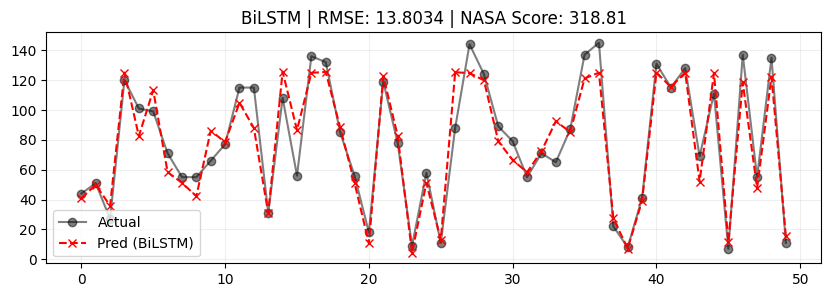


🚀 Transformer 모델 학습 시작...
✅ Transformer 학습 완료 (Best Val Loss: 0.000163)


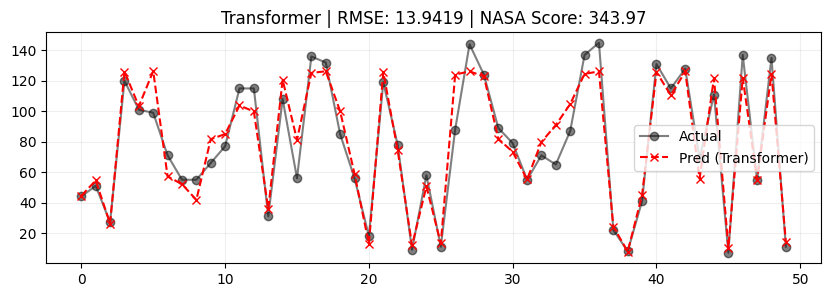


🚀 CNN+Transformer 모델 학습 시작...
✅ CNN+Transformer 학습 완료 (Best Val Loss: 0.000255)


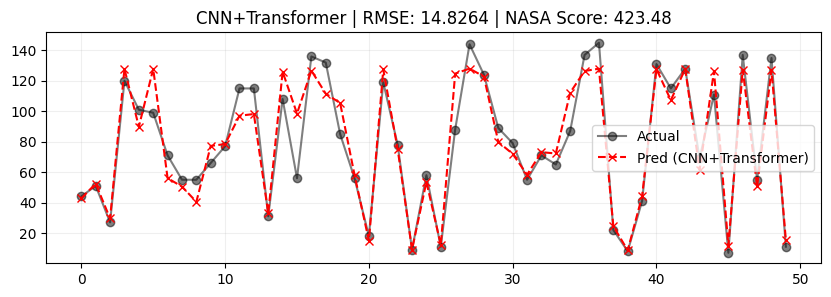


🏆 딥러닝 모델 최종 성능 비교
          Model      RMSE  NASA Score
            CNN 14.834888  399.829892
           LSTM 14.853272  481.650661
         BiLSTM 13.803388  318.812052
    Transformer 13.941871  343.969509
CNN+Transformer 14.826421  423.479335


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import math
import copy
from torch.utils.data import DataLoader, Dataset
from torch.optim.lr_scheduler import CosineAnnealingLR
from scipy.ndimage import gaussian_filter1d
from scipy.stats import mannwhitneyu
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# ==========================================
# [1] 실험 설정 구간 (CONFIG)
# ==========================================
DATA_PATH = '../../CMAPSSData/'
CONFIG = {
    'DATA_ID': 'FD003',
    'RUL_CAP': 125,
    'GAUSS_SIGMA': 2,
    'RANDOM_STATE': 42,
    'VAL_SIZE': 0.15,       # 추가: 검증 데이터 비율
    'SCALER_TYPE': 'standard', # 'standard', 'minmax'
    'SELECTED_SENSORS': ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 
                         's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21'],
    'SETTING_FEATURES': ['setting_1', 'setting_2'],
    'USE_MA': False,    'WIN_MA': 5,     # 성능 향상을 위해 이동평균 활성화 추천
    'USE_STD': True,  'WIN_STD': 60,  
    'USE_DIFF': True, 'PER_DIFF': 60,
    'USE_EMA': False,  'SPAN_EMA': 10,
    
    # 딥러닝 전용 설정
    'WINDOW_SIZE': 30,
    'BATCH_SIZE': 64,
    'EPOCHS': 50,
    'LEARNING_RATE': 0.001,
    'DROPOUT': 0.2,         # 추가: 드롭아웃 비율
    'DEVICE': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# ---------------------------------------------------------
# [2] 전처리 및 데이터셋 생성 로직
# ---------------------------------------------------------
def get_sensors_by_config(df, config):
    all_possible_sensors = [f's_{i}' for i in range(1, 22)]
    if config['SELECTED_SENSORS'] == 'all':
        sig_sensors = [s for s in all_possible_sensors if df[s].std() > 1e-6]
    elif config['SELECTED_SENSORS'] == 'auto':
        max_cycles = df.groupby('unit_nr')['time_cycles'].transform('max')
        early_stage = df[df['time_cycles'] <= 30]
        late_stage = df[df['time_cycles'] > (max_cycles - 30)]
        sig_sensors = []
        for s in all_possible_sensors:
            if df[s].std() < 1e-6: continue
            _, p = mannwhitneyu(early_stage[s], late_stage[s], alternative='two-sided')
            if p < 0.01: sig_sensors.append(s)
    elif isinstance(config['SELECTED_SENSORS'], list):
        sig_sensors = [s for s in config['SELECTED_SENSORS'] if s in df.columns]
    return sig_sensors

def add_advanced_features(df, sensors, config):
    df_res = df.copy()
    for col in sensors:
        group = df_res.groupby('unit_nr')[col]
        if config['USE_MA']:   df_res[f'{col}_ma'] = group.transform(lambda x: x.rolling(config['WIN_MA'], min_periods=1).mean())
        if config['USE_STD']:  df_res[f'{col}_std'] = group.transform(lambda x: x.rolling(config['WIN_STD'], min_periods=1).std().fillna(0))
        if config['USE_DIFF']: df_res[f'{col}_diff'] = group.transform(lambda x: x.diff(config['PER_DIFF']).fillna(0))
        if config['USE_EMA']:  df_res[f'{col}_ema'] = group.transform(lambda x: x.ewm(span=config['SPAN_EMA'], adjust=False).mean())
    return df_res

def apply_smoothing(df, sigma, sensors):
    df = df.copy().sort_values(['unit_nr', 'time_cycles'])
    for uid in df['unit_nr'].unique():
        mask = df['unit_nr'] == uid
        for col in sensors:
            df.loc[mask, col] = gaussian_filter1d(df.loc[mask, col].astype(float), sigma=sigma, mode='nearest')
    return df

# 데이터 로드
cols = ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3'] + [f's_{i}' for i in range(1, 22)]
train = pd.read_csv(f"{DATA_PATH}train_{CONFIG['DATA_ID']}.txt", sep='\s+', header=None, names=cols)
test = pd.read_csv(f"{DATA_PATH}test_{CONFIG['DATA_ID']}.txt", sep='\s+', header=None, names=cols)
y_test_actual = pd.read_csv(f"{DATA_PATH}RUL_{CONFIG['DATA_ID']}.txt", sep='\s+', header=None, names=['RUL'])['RUL'].values

base_sensors = get_sensors_by_config(train, CONFIG)
train['RUL'] = train.groupby('unit_nr')['time_cycles'].transform(lambda x: (x.max() - x).clip(upper=CONFIG['RUL_CAP']))

train = apply_smoothing(train, CONFIG['GAUSS_SIGMA'], base_sensors)
test = apply_smoothing(test, CONFIG['GAUSS_SIGMA'], base_sensors)
train = add_advanced_features(train, base_sensors, CONFIG)
test = add_advanced_features(test, base_sensors, CONFIG)

scaler = MinMaxScaler() if CONFIG['SCALER_TYPE'] == 'minmax' else StandardScaler()
X_features = base_sensors + CONFIG['SETTING_FEATURES'] + [c for c in train.columns if any(suffix in c for suffix in ['_ma', '_std', '_diff', '_ema'])]
train[X_features] = scaler.fit_transform(train[X_features])
test[X_features] = scaler.transform(test[X_features])

def create_sequences(df, window_size, feature_cols, target_col=None):
    x, y = [], []
    for uid in df['unit_nr'].unique():
        unit_df = df[df['unit_nr'] == uid]
        data = unit_df[feature_cols].values
        if target_col:
            target = unit_df[target_col].values
        for i in range(window_size, len(data) + 1):
            x.append(data[i-window_size:i])
            if target_col:
                y.append(target[i-1])
    return np.array(x), np.array(y)

def create_test_sequences(df, window_size, feature_cols):
    x = []
    for uid in df['unit_nr'].unique():
        unit_df = df[df['unit_nr'] == uid]
        if len(unit_df) >= window_size:
            x.append(unit_df[feature_cols].values[-window_size:])
        else:
            padding = np.zeros((window_size - len(unit_df), len(feature_cols)))
            x.append(np.vstack([padding, unit_df[feature_cols].values]))
    return np.array(x)

class AsymmetricLoss(nn.Module):
    def __init__(self, over_penalty=3.0, under_penalty=1.0):
        super().__init__()
        # over_penalty: 실제보다 수명을 길게(위험하게) 예측했을 때의 가중치
        # under_penalty: 실제보다 수명을 짧게(안전하게) 예측했을 때의 가중치
        self.over_penalty = over_penalty
        self.under_penalty = under_penalty

    def forward(self, y_pred, y_true):
        diff = y_pred - y_true
        squared_loss = diff ** 2
        
        # diff > 0 이면 과대 예측(늦은 정비 -> 위험), diff < 0 이면 과소 예측(이른 정비 -> 안전)
        loss = torch.where(diff > 0, squared_loss * self.over_penalty, squared_loss * self.under_penalty)
        return torch.mean(loss)

X_train_full, y_train_full = create_sequences(train, CONFIG['WINDOW_SIZE'], X_features, 'RUL')
X_test_seq = create_test_sequences(test, CONFIG['WINDOW_SIZE'], X_features)

# 🔥 개선: Target(RUL) 정규화 (0 ~ 1 스케일링)
y_train_full = y_train_full / CONFIG['RUL_CAP']

# 🔥 개선: Train / Validation 분할
X_tr, X_val, y_tr, y_val = train_test_split(X_train_full, y_train_full, test_size=CONFIG['VAL_SIZE'], random_state=CONFIG['RANDOM_STATE'])

class CMAPSSDataset(Dataset):
    def __init__(self, x, y=None):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32) if y is not None else None
    def __len__(self): return len(self.x)
    def __getitem__(self, i):
        if self.y is not None: return self.x[i], self.y[i]
        return self.x[i]

train_loader = DataLoader(CMAPSSDataset(X_tr, y_tr), batch_size=CONFIG['BATCH_SIZE'], shuffle=True)
val_loader = DataLoader(CMAPSSDataset(X_val, y_val), batch_size=CONFIG['BATCH_SIZE'], shuffle=False)
test_loader = DataLoader(CMAPSSDataset(X_test_seq), batch_size=1, shuffle=False)

# ---------------------------------------------------------
# [3] 모델 정의 구간 (Positional Encoding 및 Dropout 추가)
# ---------------------------------------------------------
input_dim = len(X_features)
win_size = CONFIG['WINDOW_SIZE']
dropout_rate = CONFIG['DROPOUT']

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(input_dim, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(64, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Flatten()
        )
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(32 * win_size, 1)
    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv(x)
        x = self.dropout(x)
        return self.fc(x).squeeze()

class RNNModel(nn.Module):
    def __init__(self, bidirectional=False):
        super().__init__()
        self.rnn = nn.LSTM(input_dim, 64, num_layers=2, batch_first=True, 
                           bidirectional=bidirectional, dropout=dropout_rate)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(128 if bidirectional else 64, 1)
    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out).squeeze()

class TransformerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Linear(input_dim, 64)
        self.pos_encoder = PositionalEncoding(64) # 🔥 개선: Transformer에 Positional Encoding 추가
        encoder_layer = nn.TransformerEncoderLayer(d_model=64, nhead=4, dim_feedforward=128, 
                                                   dropout=dropout_rate, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(64, 1)
    def forward(self, x):
        x = self.embedding(x)
        x = self.pos_encoder(x)
        x = self.transformer(x)
        x = self.dropout(x[:, -1, :])
        return self.fc(x).squeeze()

class CNNTransformer(nn.Module):
    def __init__(self, d_model=64):
        super().__init__()
        self.conv = nn.Conv1d(input_dim, d_model, kernel_size=3, padding=1)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=4, dropout=dropout_rate, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(d_model, 1)
    def forward(self, x):
        x = self.conv(x.transpose(1, 2)).transpose(1, 2)
        x = self.pos_encoder(x)
        x = self.transformer(x)
        x = self.dropout(x[:, -1, :])
        return self.fc(x).squeeze()

# ---------------------------------------------------------
# [4] 학습 및 평가 루프 (개선된 안정화 학습)
# ---------------------------------------------------------
def get_nasa_score(y_true, y_pred):
    d = y_pred - y_true
    return np.sum(np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1))

models_dict = {
    'CNN': CNNModel(),
    'LSTM': RNNModel(bidirectional=False),
    'BiLSTM': RNNModel(bidirectional=True),
    'Transformer': TransformerModel(),
    'CNN+Transformer': CNNTransformer()
}

results = []

for name, model in models_dict.items():
    print(f"\n🚀 {name} 모델 학습 시작...")
    model.to(CONFIG['DEVICE'])
    
    # 🔥 개선: MSE 대신 SmoothL1Loss 사용 (이상치에 더 강력함)
    criterion = nn.SmoothL1Loss() 
#    criterion = AsymmetricLoss(over_penalty=5.0, under_penalty=1.0)

    if name in ['BiLSTM', 'Transformer', 'CNN+Transformer']:
        optimizer = optim.AdamW(model.parameters(), lr=CONFIG['LEARNING_RATE'], weight_decay=1e-4)
        scheduler = CosineAnnealingLR(optimizer, T_max=CONFIG['EPOCHS'])
    else:
        optimizer = optim.Adam(model.parameters(), lr=CONFIG['LEARNING_RATE'])
        scheduler = None
    
    best_val_loss = float('inf')
    best_model_weights = copy.deepcopy(model.state_dict())
    
    for epoch in range(CONFIG['EPOCHS']):
        # --- Training ---
        model.train()
        train_loss = 0.0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(CONFIG['DEVICE']), batch_y.to(CONFIG['DEVICE'])
            optimizer.zero_grad()
            output = model(batch_x)
            loss = criterion(output, batch_y)
            loss.backward()
            
            # 🔥 개선: Gradient Clipping으로 가중치 폭발 방지
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            train_loss += loss.item()
            
        if scheduler:
            scheduler.step()
            
        # --- Validation (🔥 개선: 검증 데이터 평가 및 베스트 모델 저장) ---
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(CONFIG['DEVICE']), batch_y.to(CONFIG['DEVICE'])
                output = model(batch_x)
                loss = criterion(output, batch_y)
                val_loss += loss.item()
                
        val_loss /= len(val_loader)
        
        # 최적의 모델 가중치 저장
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_weights = copy.deepcopy(model.state_dict())

    print(f"✅ {name} 학습 완료 (Best Val Loss: {best_val_loss:.6f})")
    
    # --- Testing (최적 가중치 로드) ---
    model.load_state_dict(best_model_weights)
    model.eval()
    y_pred = []
    
    with torch.no_grad():
        for batch_x in test_loader:
            batch_x = batch_x.to(CONFIG['DEVICE'])
            # 🔥 개선: 예측 결과에 다시 RUL_CAP(125)을 곱하여 스케일 원복
            pred_val = model(batch_x).item() * CONFIG['RUL_CAP']
            y_pred.append(pred_val)
    
    y_pred = np.array(y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
    score = get_nasa_score(y_test_actual, y_pred)
    
    plt.figure(figsize=(10, 3))
    plt.plot(y_test_actual[:50], 'ko-', label='Actual', alpha=0.5)
    plt.plot(y_pred[:50], 'rx--', label=f'Pred ({name})')
    plt.title(f"{name} | RMSE: {rmse:.4f} | NASA Score: {score:.2f}")
    plt.legend(); plt.grid(True, alpha=0.2); plt.show()
    
    results.append([name, rmse, score])

print("\n🏆 딥러닝 모델 최종 성능 비교")
print(pd.DataFrame(results, columns=['Model', 'RMSE', 'NASA Score']).to_string(index=False))